In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import torch

device= 'cuda' if torch.cuda.is_available() else 'cpu'

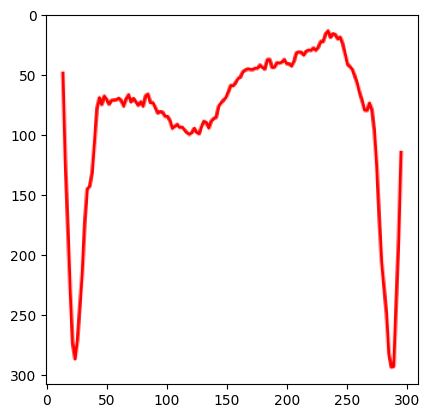

[[310 308]]


In [2]:
train_df= pd.read_csv("train.csv")
test_df= pd.read_csv("test.csv")

plt.imshow(Image.open(train_df.iloc[0]['image_path']))
plt.show()

unique_sizes= []

for _, row in train_df.iterrows():
    unique_sizes.append(Image.open(row['image_path']).size)

print(np.unique(unique_sizes, axis= 0))


In [3]:
from torch.utils.data import Dataset, DataLoader

class ImageDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        
        row= self.df.iloc[idx]

        img_path= row['image_path']
        img= Image.open(img_path)

        if img.mode == 'P':
            img= img.convert("RGBA")
        img= img.convert("RGB")
        
        if self.transform:
            img= self.transform(img)

        if "label" not in row:
            return img

        label= torch.tensor(row['label'], dtype= torch.long)

        return img, label

In [4]:
from torchvision import transforms
train_transforms= transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
]) 

test_transforms= transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
]) 

In [5]:
train_dataset= ImageDataset(train_df, transform=train_transforms)
test_dataset= ImageDataset(test_df, transform=test_transforms)

train_loader= DataLoader(train_dataset, batch_size=32, shuffle= True)
test_loader= DataLoader(test_dataset, batch_size=32, shuffle= False)

In [6]:
import torch.nn as nn
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

model= efficientnet_b0(weights= EfficientNet_B0_Weights.DEFAULT)
model.classifier[1]= nn.Linear(model.classifier[1].in_features, 2)
model.to(device)

epochs= 5
lr= 1e-4

criterion= nn.CrossEntropyLoss()
optimizer= torch.optim.AdamW(model.parameters(), lr= lr)

for epoch in range(epochs):
    running_loss= 0.0
    model.train()
    for images, labels in train_loader:
        images, labels= images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs= model(images)
        loss= criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss+= loss.item()
    running_loss/= len(train_loader)
    print(f"Epoch:{epoch+ 1}, Loss:{running_loss}")

Epoch:1, Loss:0.1044202243797481
Epoch:2, Loss:0.025973430467769502
Epoch:3, Loss:0.012367846684530377
Epoch:4, Loss:0.010273867837153375
Epoch:5, Loss:0.0059248150190105665


In [7]:
predictions=[]

with torch.no_grad():
    model.eval()
    for images in test_loader:
        images= images.to(device)

        outputs= model(images)
        preds= torch.argmax(outputs, 1)
        predictions.extend(preds.cpu().numpy())

answer= []

for idx, row in test_df.iterrows():
    answer.append({
        'image_path': row['image_path'],
        'label': predictions[idx]
    })

pd.DataFrame(answer).to_csv("submission.csv", index= False)